In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
ORDEM_MESES = {
    "Janeiro": 1, 
    "Fevereiro": 2, 
    "Março": 3, 
    "Abril": 4,
    "Maio": 5, 
    "Junho": 6, 
    "Julho": 7, 
    "Agosto": 8,
    "Setembro": 9, 
    "Outubro": 10, 
    "Novembro": 11, 
    "Dezembro": 12,
}

df = pd.read_csv("../CSVs/Dados unidos/dados_mensais_unificado.csv")
df["Porcentagens"] = df["Porcentagens"].str.replace("%", "").astype(float)

df_monitores = df[df["Categoria"] == "Primary Display Resolution"].copy()
df_monitores["Data"] = pd.to_datetime(
    df_monitores["Ano"].astype(str) + "-" + df_monitores["Mês"].map(ORDEM_MESES).astype(str) + "-01"
)

print(f"Linhas: {len(df_monitores)}")
print(f"Resoluções diferentes: {df_monitores['Especificação'].nunique()}")
df_monitores.head()

Linhas: 1585
Resoluções diferentes: 24


,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano,Data
179,Primary Display Resolution,1024 x 768,0.64,0.00%,Janeiro,2019,2019-01-01
180,Primary Display Resolution,1280 x 1024,2.16,+0.03%,Janeiro,2019,2019-01-01
181,Primary Display Resolution,1280 x 720,0.42,0.00%,Janeiro,2019,2019-01-01
182,Primary Display Resolution,1280 x 800,0.82,-0.04%,Janeiro,2019,2019-01-01
183,Primary Display Resolution,1360 x 768,1.95,+0.05%,Janeiro,2019,2019-01-01


In [3]:
print(f"Nulos: {df_monitores['Especificação'].isnull().sum()}")

df_monitores.groupby("Especificação")["Porcentagens"].mean().sort_values(ascending=False).head(10)

Nulos: 0


Especificação
1920 x 1080    61.679326
2560 x 1440    13.037191
1366 x 768      6.287191
3840 x 2160     2.922360
2560 x 1600     2.861500
Other           2.319101
1440 x 900      2.013483
1600 x 900      1.697753
3440 x 1440     1.613483
1680 x 1050     1.191798
Name: Porcentagens, dtype: float64

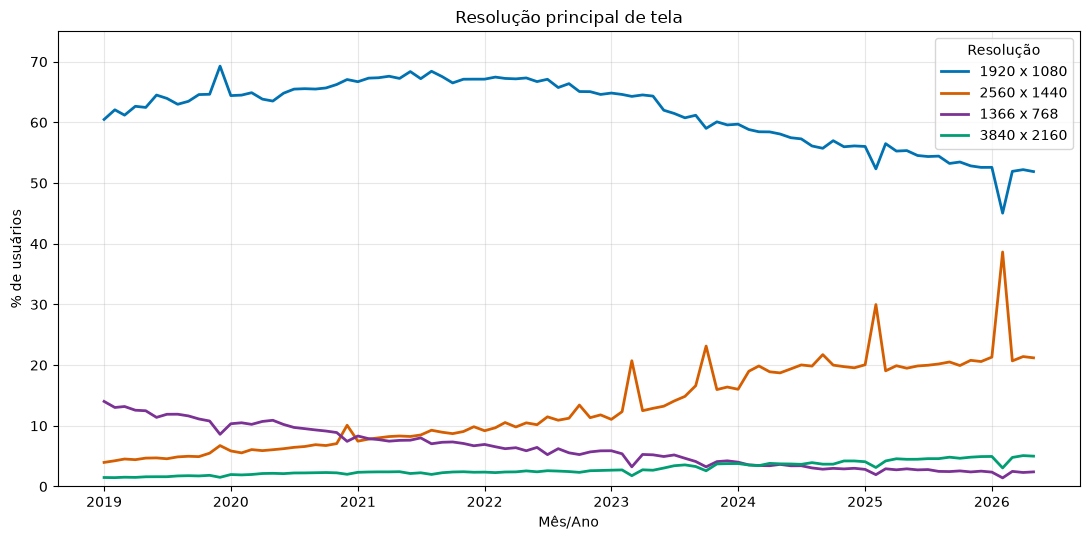

In [4]:
resolucoes = ["1920 x 1080", "2560 x 1440", "1366 x 768", "3840 x 2160"]
cores = {
    "1920 x 1080": "#0072B2",
    "2560 x 1440": "#D55E00",
    "1366 x 768": "#7B3294",
    "3840 x 2160": "#009E73",
}

tabela = df_monitores.pivot_table(index="Data", columns="Especificação", values="Porcentagens") # tranforma na pivot com datas como índice e resoluções como colunas

plt.figure(figsize=(11, 5.5))

for resolucao in resolucoes:
    serie = tabela[resolucao].dropna()
    plt.plot(serie.index, serie, color=cores[resolucao], linewidth=2, label=resolucao)

plt.title("Resolução principal de tela")
plt.xlabel("Mês/Ano")
plt.ylabel("% de usuários")
plt.ylim(0, 75)
plt.legend(title="Resolução")
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

In [5]:
comparacao = tabela.iloc[[0, -1]][resolucoes].T
comparacao.columns = ["Jan/2019", "Mai/2026"]
comparacao["Diferença"] = (comparacao["Mai/2026"] - comparacao["Jan/2019"]).round(2)
comparacao

,Jan/2019,Mai/2026,Diferença
Especificação,,,
1920 x 1080,60.48,51.89,-8.59
2560 x 1440,3.97,21.20,17.23
1366 x 768,14.02,2.41,-11.61
3840 x 2160,1.48,5.00,3.52


1920 x 1080: -0.346 %/mês | R² = 0.95
2560 x 1440: +0.283 %/mês | R² = 0.65
Interceptação: o 2560 x 1440 ultrapassa o 1920 x 1080 em 10/2029


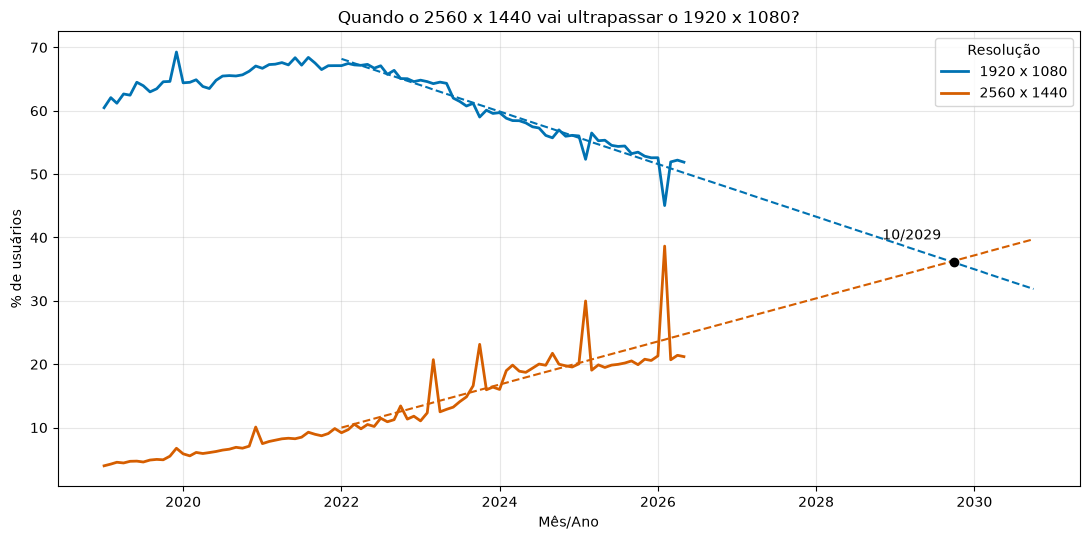

In [ ]:
tendencia = tabela.loc["2022-01-01":, ["1920 x 1080", "2560 x 1440"]] # só a fase de queda: antes de 2022 o 1920 x 1080 ainda estava subindo
X = ((tendencia.index.year - 2022) * 12 + tendencia.index.month - 1).to_numpy().reshape(-1, 1) # a data vira o nº de meses desde Jan/2022

modelo1080 = LinearRegression().fit(X, tendencia["1920 x 1080"])
modelo1440 = LinearRegression().fit(X, tendencia["2560 x 1440"])

mesesAteCruzar = (modelo1080.intercept_ - modelo1440.intercept_) / (modelo1440.coef_[0] - modelo1080.coef_[0]) # a1 + b1x = a2 + b2x
dataCruzamento = pd.Timestamp("2022-01-01") + pd.DateOffset(months=int(round(mesesAteCruzar)))
porcentagemCruzamento = modelo1080.intercept_ + modelo1080.coef_[0] * mesesAteCruzar

print(f"1920 x 1080: {modelo1080.coef_[0]:+.3f} %/mês | R² = {modelo1080.score(X, tendencia['1920 x 1080']):.2f}")
print(f"2560 x 1440: {modelo1440.coef_[0]:+.3f} %/mês | R² = {modelo1440.score(X, tendencia['2560 x 1440']):.2f}")
print(f"Interceptação: o 2560 x 1440 ultrapassa o 1920 x 1080 em {dataCruzamento.strftime('%m/%Y')}")

futuro = pd.date_range("2022-01-01", dataCruzamento + pd.DateOffset(months=12), freq="MS")
X_futuro = ((futuro.year - 2022) * 12 + futuro.month - 1).to_numpy().reshape(-1, 1)

plt.figure(figsize=(11, 5.5))

for resolucao, modelo in [("1920 x 1080", modelo1080), ("2560 x 1440", modelo1440)]:
    plt.plot(tabela[resolucao].dropna(), color=cores[resolucao], linewidth=2, label=resolucao)
    plt.plot(futuro, modelo.predict(X_futuro), color=cores[resolucao], linewidth=1.5, linestyle="--")

plt.plot(dataCruzamento, porcentagemCruzamento, "o", color="black", zorder=5)
plt.annotate(dataCruzamento.strftime("%m/%Y"), xy=(dataCruzamento, porcentagemCruzamento), xytext=(-52, 16), textcoords="offset points")
plt.title("Quando o 2560 x 1440 vai ultrapassar o 1920 x 1080?")
plt.xlabel("Mês/Ano")
plt.ylabel("% de usuários")
plt.legend(title="Resolução")
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()